In [10]:
import os
import re
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

#### Utility function

In [11]:
def extract_eom(name):
    match = re.search(r'P=(\d+)', name)
    return int(match.group(1)) if match else None

def load_tif(folder):
    for f in os.listdir(folder):
        if f.endswith(".tif"):
            return tiff.imread(os.path.join(folder, f))
    return None

# depth（PositionZ）
def load_z_positions(folder):
    for f in os.listdir(folder):
        if f.endswith(".companion.ome"):
            tree = ET.parse(os.path.join(folder, f))
            root = tree.getroot()

            z_list = []
            for elem in root.iter():
                if 'TheZ' in elem.attrib and 'PositionZ' in elem.attrib:
                    z_idx = int(elem.attrib['TheZ']) - 1
                    z_val = float(elem.attrib['PositionZ'])
                    z_list.append((z_idx, z_val))

            z_list.sort(key=lambda x: x[0])
            zs = np.array([z[1] for z in z_list])

            return zs
    return None

def compute_bg(bg_dir):
    imgs = []
    for f in os.listdir(bg_dir):
        if f.endswith(".tif"):
            imgs.append(tiff.imread(os.path.join(bg_dir, f)))
    return np.mean(imgs, axis=0)

# top % pixel mean
def top_percent_mean(image, percent):
    flat = image.flatten()
    threshold = np.percentile(flat, 100 - percent)
    selected = flat[flat >= threshold]
    return np.mean(selected)


#### Import the dataset

In [17]:
root_dir = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/code/20260403_G+R_EAL_16X/green_16x/x1"
bg_dir = os.path.join(root_dir, "bg")

# EOM vs Power (lookup table)
excel_path = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/code/20260403_G+R_EAL_16X/lookuptable.xlsx"

# Use the top 1% pixel mean as the signal
top_percent = 1

##### Read the dataset and obtain depth info 

In [18]:
folders = os.listdir(root_dir)

eom_map = {}
for f in folders:
    e = extract_eom(f)
    if e is not None:
        eom_map[e] = os.path.join(root_dir, f)

eoms_sorted = sorted(eom_map.keys())

ref_stack = load_tif(eom_map[max(eoms_sorted)]).astype(float)
z_positions = load_z_positions(eom_map[max(eoms_sorted)])

bg_stack = compute_bg(bg_dir)

df = pd.read_excel(excel_path)
eom_to_power = dict(zip(df.iloc[:,0], df.iloc[:,1]))

all_data = {}

for eom in eoms_sorted:
    stack = load_tif(eom_map[eom]).astype(float)

    stack = stack - bg_stack
    stack[stack < 0] = 0

    if eom not in eom_to_power:
        continue

    power = eom_to_power[eom]

    for z in range(stack.shape[0]):
        if z not in all_data:
            all_data[z] = {
                "power": [],
                "eom": [],
                "signal": []
            }

        img = stack[z]

        signal = top_percent_mean(img, top_percent)

        all_data[z]["power"].append(power)
        all_data[z]["eom"].append(eom)
        all_data[z]["signal"].append(signal)

#### 2P verification for each depth


Depth = -884.95 µm
BEST : k=1.581, EOMs=[13 18 23]
RIGHT: k=1.471, EOMs=[13 18 23 28]


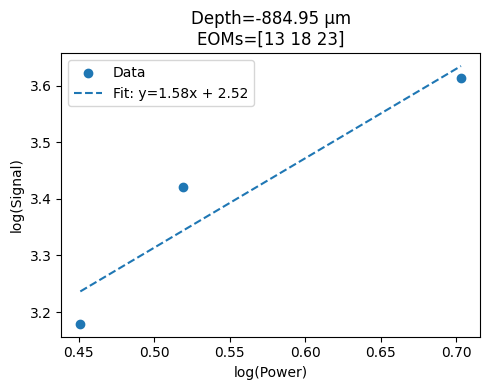


Depth = -874.95 µm
BEST : k=1.983, EOMs=[23 28 33]
LEFT : k=2.215, EOMs=[18 23 28 33]
RIGHT: k=1.866, EOMs=[23 28 33 39]


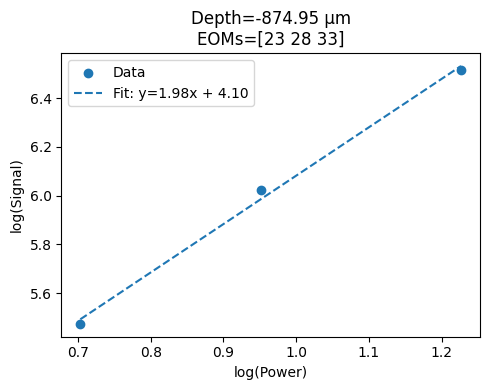


Depth = -864.95 µm
BEST : k=1.979, EOMs=[23 28 33]
LEFT : k=2.217, EOMs=[18 23 28 33]
RIGHT: k=1.888, EOMs=[23 28 33 39]


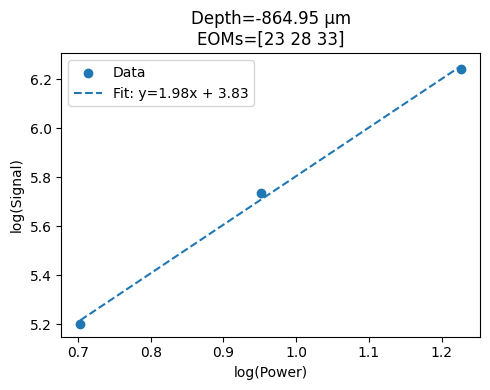


Depth = -854.95 µm
BEST : k=2.057, EOMs=[18 23 28 33 39]
LEFT : k=2.281, EOMs=[13 18 23 28 33 39]
RIGHT: k=1.921, EOMs=[18 23 28 33 39 44]


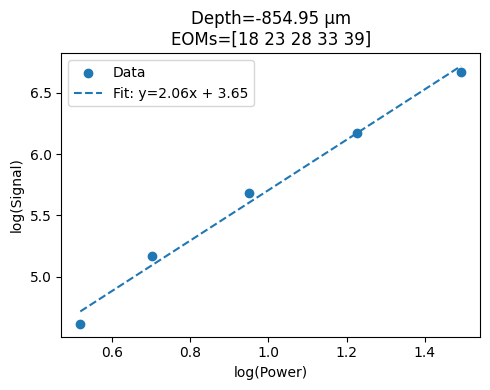


Depth = -844.95 µm
BEST : k=2.004, EOMs=[23 28 33]
LEFT : k=2.239, EOMs=[18 23 28 33]
RIGHT: k=1.934, EOMs=[23 28 33 39]


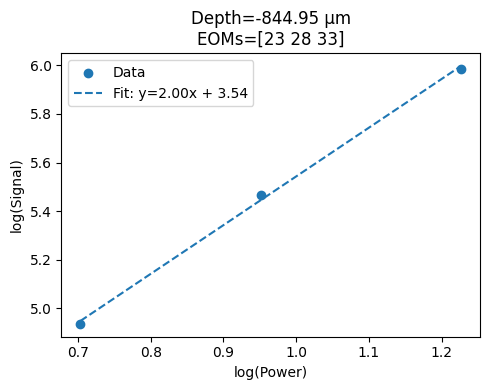


Depth = -834.95 µm
BEST : k=1.990, EOMs=[18 23 28 33 39 44]
LEFT : k=2.189, EOMs=[13 18 23 28 33 39 44]
RIGHT: k=1.892, EOMs=[18 23 28 33 39 44 49]


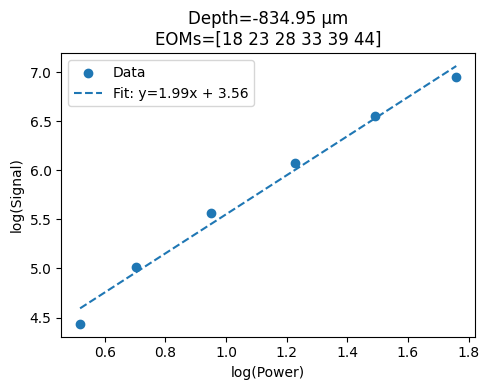


Depth = -824.95 µm
BEST : k=2.023, EOMs=[18 23 28 33 39]
LEFT : k=2.227, EOMs=[13 18 23 28 33 39]
RIGHT: k=1.912, EOMs=[18 23 28 33 39 44]


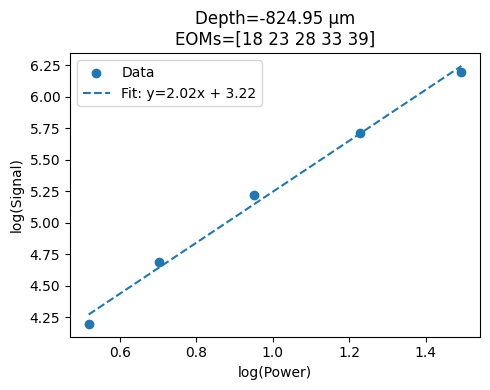


Depth = -814.95 µm
BEST : k=1.995, EOMs=[18 23 28 33 39]
LEFT : k=2.149, EOMs=[13 18 23 28 33 39]
RIGHT: k=1.895, EOMs=[18 23 28 33 39 44]


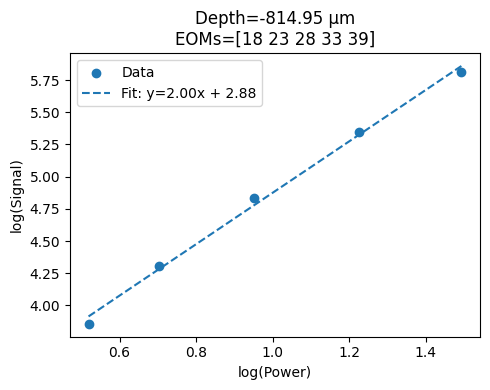


Depth = -804.95 µm
BEST : k=1.999, EOMs=[18 23 28 33 39]
LEFT : k=2.133, EOMs=[13 18 23 28 33 39]
RIGHT: k=1.901, EOMs=[18 23 28 33 39 44]


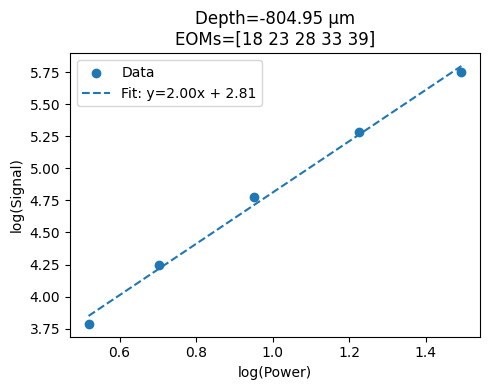


Depth = -794.95 µm
BEST : k=1.915, EOMs=[13 18 23 28 33]
RIGHT: k=1.861, EOMs=[13 18 23 28 33 39]


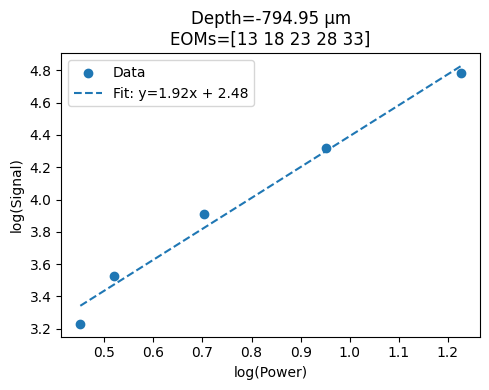


Depth = -784.95 µm
BEST : k=2.015, EOMs=[13 18 23 28]
RIGHT: k=1.879, EOMs=[13 18 23 28 33]


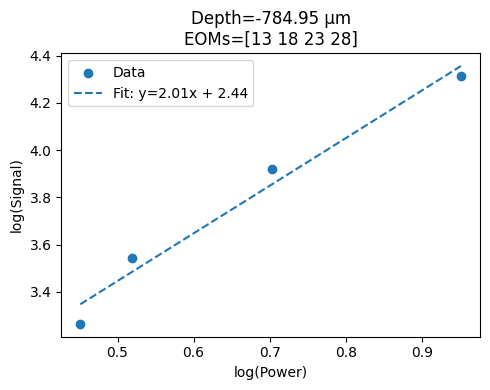


Depth = -774.95 µm
BEST : k=2.020, EOMs=[13 18 23]
RIGHT: k=1.839, EOMs=[13 18 23 28]


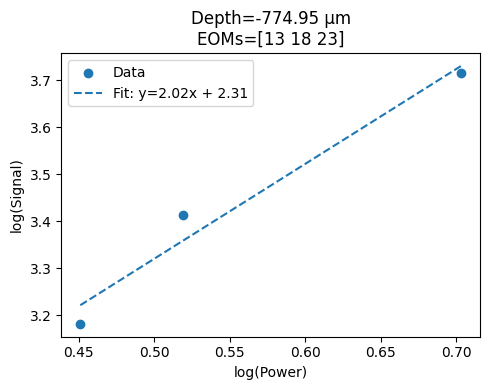


Depth = -764.95 µm
BEST : k=1.852, EOMs=[13 18 23]
RIGHT: k=1.616, EOMs=[13 18 23 28]


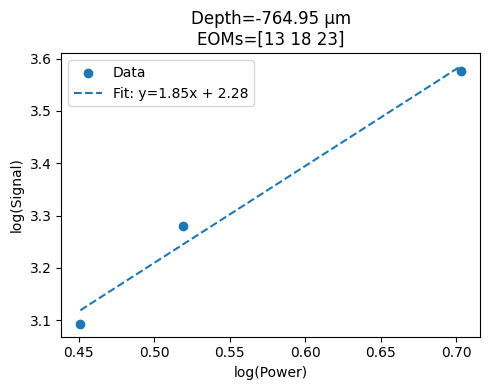


Depth = -754.95 µm
BEST : k=2.027, EOMs=[13 18 23]
RIGHT: k=1.639, EOMs=[13 18 23 28]


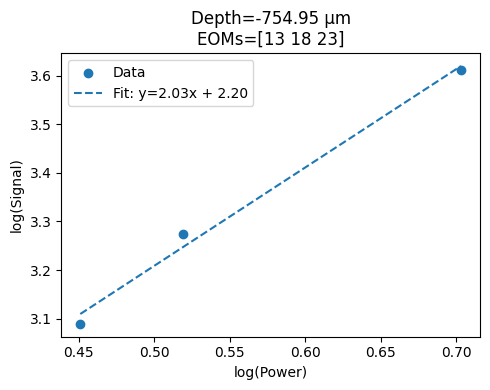


Depth = -744.95 µm
BEST : k=2.006, EOMs=[13 18]
RIGHT: k=0.964, EOMs=[13 18 23]


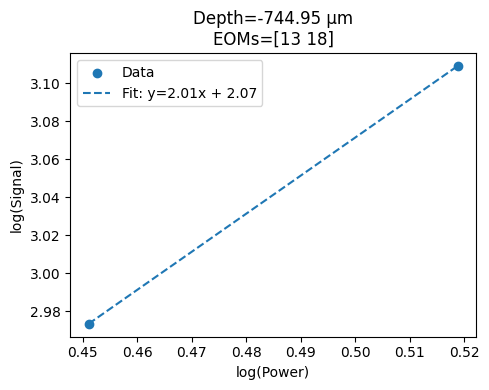


Depth = -734.95 µm
BEST : k=1.433, EOMs=[44 49]
LEFT : k=1.416, EOMs=[39 44 49]


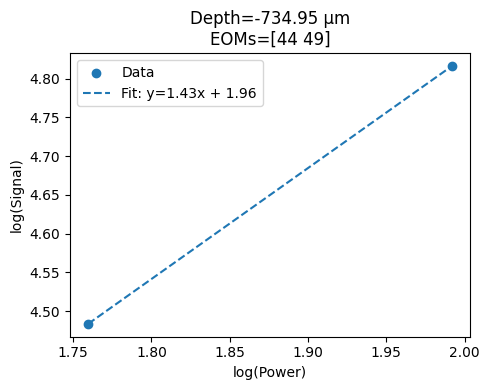


Depth = -724.95 µm
BEST : k=1.339, EOMs=[44 49]
LEFT : k=1.314, EOMs=[39 44 49]


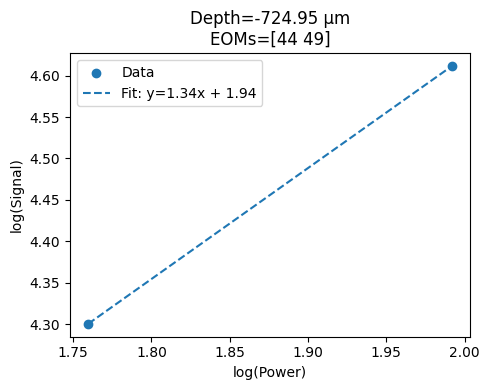


Depth = -714.95 µm
BEST : k=1.317, EOMs=[44 49]
LEFT : k=1.277, EOMs=[39 44 49]


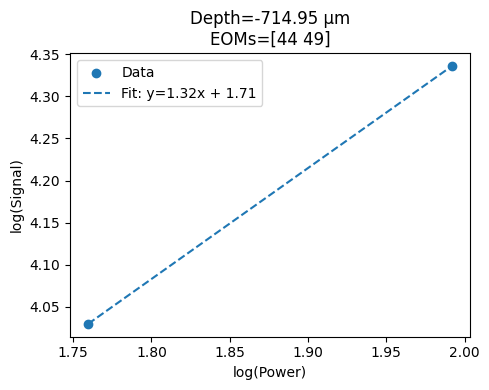


Depth = -704.95 µm
BEST : k=1.305, EOMs=[44 49]
LEFT : k=1.109, EOMs=[39 44 49]


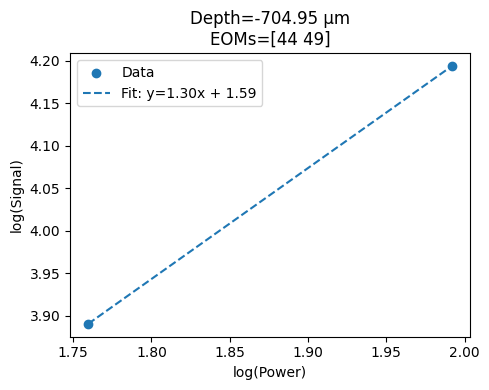


Depth = -694.95 µm
BEST : k=1.234, EOMs=[44 49]
LEFT : k=1.151, EOMs=[39 44 49]


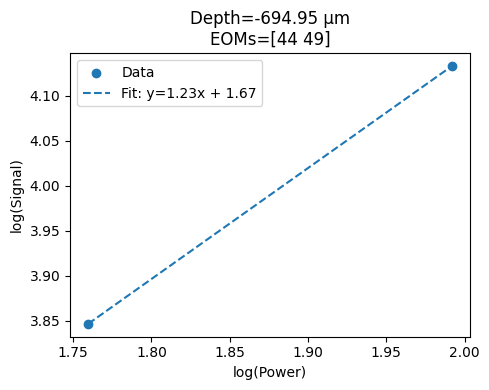


Depth = -684.95 µm
BEST : k=1.251, EOMs=[44 49]
LEFT : k=1.096, EOMs=[39 44 49]


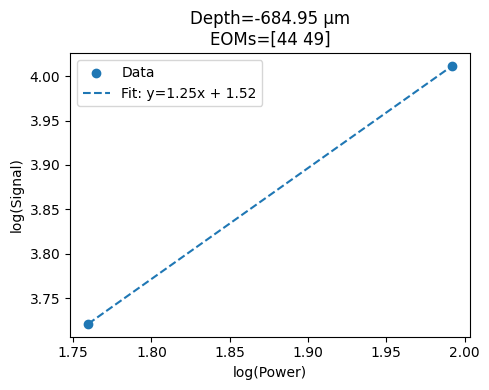

Analysis done.


In [19]:
results_table = []

for z in sorted(all_data.keys()):
    powers = np.array(all_data[z]["power"])
    eoms_arr = np.array(all_data[z]["eom"])
    signals = np.array(all_data[z]["signal"])

    valid = (powers > 0) & (signals > 0)

    powers = powers[valid]
    eoms_arr = eoms_arr[valid]
    signals = signals[valid]

    order = np.argsort(powers)
    powers = powers[order]
    eoms_arr = eoms_arr[order]
    signals = signals[order]

    N = len(powers)
    if N < 3:
        continue

    candidates = []

    for start in range(N):
        for end in range(start+2, N+1):
            if (end - start) > (N - 1):
                continue

            sub_p = powers[start:end]
            sub_s = signals[start:end]
            sub_e = eoms_arr[start:end]

            k, _ = np.polyfit(np.log(sub_p), np.log(sub_s), 1)

            candidates.append({
                "start": start,
                "end": end,
                "slope": k,
                "eoms": sub_e,
                "powers": sub_p,
                "signals": sub_s
            })

    # ===== 找最优 =====
    slopes = np.array([c["slope"] for c in candidates])
    deltas = np.abs(slopes - 2)

    best_idx = np.argmin(deltas)
    best = candidates[best_idx]

    best_slope = best["slope"]
    best_eom = np.max(best["eoms"])
    best_power = np.max(best["powers"])

    def compute_subset(start, end):
        sub_p = powers[start:end]
        sub_s = signals[start:end]
        sub_e = eoms_arr[start:end]
        k, _ = np.polyfit(np.log(sub_p), np.log(sub_s), 1)
        return k, sub_e

    left = None
    right = None

    if best["start"] > 0:
        left = (best["start"] - 1, best["end"])

    if best["end"] < N:
        right = (best["start"], best["end"] + 1)


    depth_val = z_positions[z] if z_positions is not None else z

    print(f"\nDepth = {depth_val:.2f} µm")
    print(f"BEST : k={best_slope:.3f}, EOMs={best['eoms']}")

    if left:
        k_l, e_l = compute_subset(*left)
        print(f"LEFT : k={k_l:.3f}, EOMs={e_l}")

    if right:
        k_r, e_r = compute_subset(*right)
        print(f"RIGHT: k={k_r:.3f}, EOMs={e_r}")

    # =========================
    # log-log plot
    # =========================
    logP = np.log(best["powers"])
    logS = np.log(best["signals"])

    k, b = np.polyfit(logP, logS, 1)

    x_fit = np.linspace(logP.min(), logP.max(), 100)
    y_fit = k * x_fit + b

    plt.figure(figsize=(5,4))

    plt.scatter(logP, logS, label='Data')
    plt.plot(x_fit, y_fit, label=f'Fit: y={k:.2f}x + {b:.2f}', linestyle='--')

    plt.title(f"Depth={depth_val:.2f} µm\nEOMs={best['eoms']}")
    plt.xlabel("log(Power)")
    plt.ylabel("log(Signal)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    results_table.append([depth_val, best_slope, best_eom, best_power])

print("Analysis done.")

#### Print the results


===== Final Table =====
    Depth     Slope  Best EOM  Power
0  -864.5  1.580194        49   7.33
1  -854.5  2.025264        44   5.81
2  -844.5  2.009529        49   7.33
3  -834.5  2.010613        39   4.45
4  -824.5  1.983132        28   2.59
5  -814.5  2.016640        33   3.41
6  -804.5  2.003017        49   7.33
7  -794.5  2.042038        49   7.33
8  -784.5  1.984205        49   7.33
9  -774.5  2.061412        49   7.33
10 -764.5  2.021437        28   2.59
11 -754.5  2.033378        39   4.45
12 -744.5  2.036685        33   3.41
13 -734.5  1.807337        44   5.81
14 -724.5  1.971452        18   1.68
15 -714.5  2.006423        49   7.33
16 -704.5  1.957548        49   7.33
17 -694.5  1.997139        28   2.59
18 -684.5  2.026230        33   3.41
19 -674.5  2.013766        39   4.45
20 -664.5  1.916900        44   5.81
21 -654.5  1.995227        49   7.33
22 -644.5  1.938402        39   4.45
23 -634.5  1.936970        39   4.45
24 -624.5  1.312671        44   5.81
25 -614.5  2.

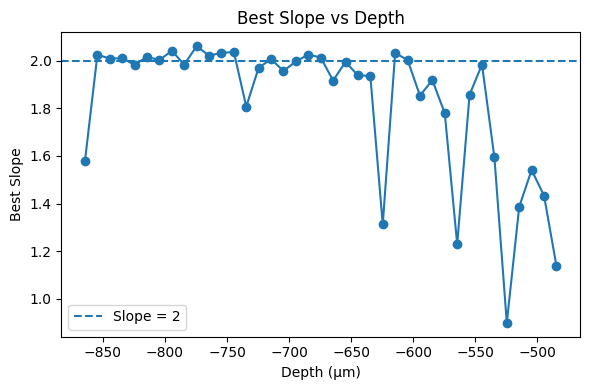

In [6]:
df_out = pd.DataFrame(
    results_table,
    columns=["Depth", "Slope", "Best EOM", "Power"]
)

save_path = os.path.join(root_dir, "depth_analysis_topPercent.xlsx")
df_out.to_excel(save_path, index=False)

print("\n===== Final Table =====")
print(df_out)

# =========================
# 📌 Depth vs Best Slope Plot
# =========================

depths = df_out["Depth"].values
best_slopes = df_out["Slope"].values 

plt.figure(figsize=(6,4))

plt.plot(depths, best_slopes, marker='o')
plt.axhline(2, linestyle='--', label='Slope = 2')

plt.xlabel("Depth (µm)")
plt.ylabel("Best Slope")
plt.title("Best Slope vs Depth")

plt.legend()
plt.tight_layout()

# 保存
plot_path = os.path.join(root_dir, "depth_vs_slope.png")
plt.savefig(plot_path, dpi=300)

plt.show()


#### Calculate the effective attenuation length (EAL)

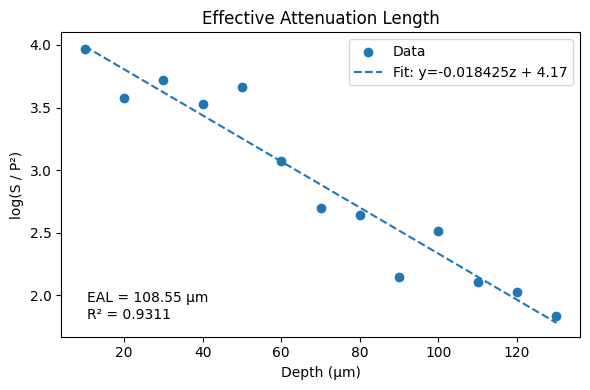

In [27]:
# =========================
# 📌 Attenuation Length
# =========================

# choose a subset of depths for EAL calculation (usually the depth range where slope is close to 2)
z_min_idx = 1 
z_max_idx = 13
step_um = 10 # step size for each z (assuming 10 µm per step)  

z_list = []
log_SP2_list = []

for z in range(z_min_idx, z_max_idx + 1):

    depth_val = z * step_um

    row = df_out.iloc[z]
    best_eom = row["Best EOM"]

    eoms = np.array(all_data[z]["eom"])
    powers = np.array(all_data[z]["power"])
    signals = np.array(all_data[z]["signal"])

    order = np.argsort(powers)
    eoms = eoms[order]
    powers = powers[order]
    signals = signals[order]

    idx = np.where(eoms == best_eom)[0]

    if len(idx) == 0 or idx[0] == 0:
        continue

    idx = idx[0]

    use_idx = idx - 1

    P = powers[use_idx]
    S = signals[use_idx]

    if P <= 0 or S <= 0:
        continue

    value = np.log(S / (P**2))

    z_list.append(depth_val)
    log_SP2_list.append(value)

z_arr = np.array(z_list)
y_arr = np.array(log_SP2_list)

# =========================
# Linear fitting 
# =========================
k, b = np.polyfit(z_arr, y_arr, 1)

attenuation_length = -2 / k

# calculate the R² value
y_pred = k * z_arr + b

ss_res = np.sum((y_arr - y_pred) ** 2)
ss_tot = np.sum((y_arr - np.mean(y_arr)) ** 2)

r_squared = 1 - ss_res / ss_tot

plt.figure(figsize=(6,4))

plt.scatter(z_arr, y_arr, label='Data')

z_fit = np.linspace(z_arr.min(), z_arr.max(), 100)
y_fit = k * z_fit + b

plt.plot(z_fit, y_fit, label=f'Fit: y={k:.6f}z + {b:.2f}', linestyle='--')

plt.xlabel("Depth (µm)")
plt.ylabel("log(S / P²)")
plt.title("Effective Attenuation Length")

plt.text(
    0.05, 0.05,
    f"EAL = {attenuation_length:.2f} µm\nR² = {r_squared:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment='bottom'
)

plt.legend()
plt.tight_layout()

save_path = os.path.join(root_dir, "EAL.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()